<a href="https://colab.research.google.com/github/dewianggrainimeita/PCVK_Ganjil_2026/blob/main/Pertemuan%203/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

== Modul 3 - Operasi Citra Sederhana ==

Praktikum

In [23]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob
from google.colab import drive
from google.colab.patches import cv2_imshow

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Transformasi Linear Brightness

Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 30


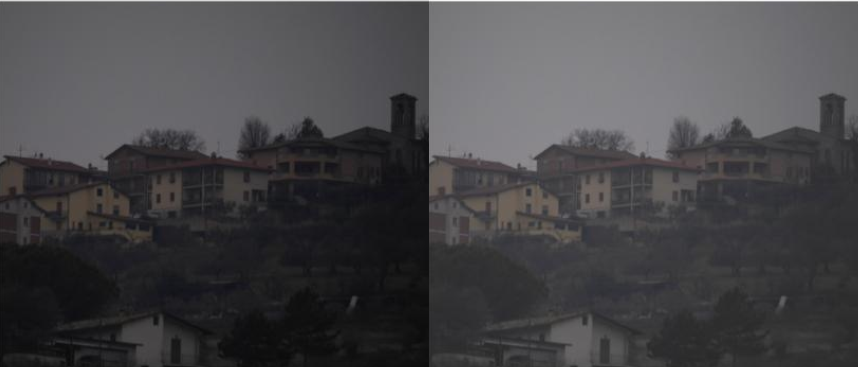

In [24]:
# Transformasi Linier Brightness
# Formula: g(x,y) = f(x,y) + b

print('Mengubah tingkat kecerahan citra')
print('--------------------------------')

try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

# Sesuaikan path dengan lokasi folder di Drive
original = cv.imread('/content/drive/MyDrive/PCVK/image/rumah.png')

if original is not None:
    brightness_image = np.zeros(original.shape, original.dtype)

    # Akses per piksel dengan truncate np.clip
    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                brightness_image[y, x, c] = np.clip(original[y, x, c] + brightness, 0, 255)

    final_frame = cv.hconcat((original, brightness_image))
    cv2_imshow(final_frame)
else:
    print("Gambar tidak ditemukan.")

Tugas Praktikum

1. Inverse Citra
Formula: $g(x) = 255 - f(x)$

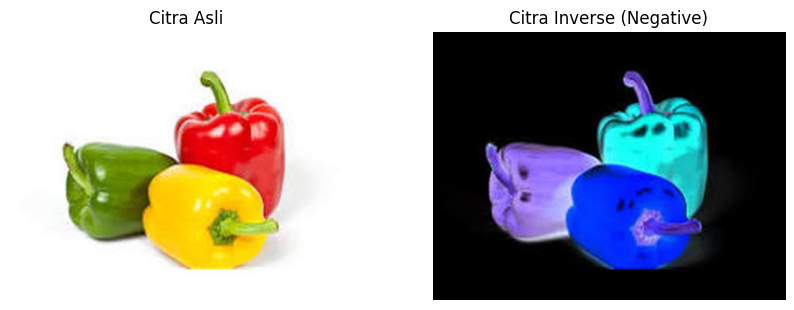

In [25]:
# Load gambar
img = cv.imread('/content/drive/MyDrive/PCVK/image/Paprika.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Operasi Inverse Citra
img_inverse = 255 - img_rgb

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_inverse)
plt.title('Citra Inverse (Negative)')
plt.axis('off')
plt.show()

2. Transformasi Contrast dan Brightness
Formula: $g(x,y) = a \cdot f(x,y) + b$ atau menggunakan Contrast Correction Factor $F = \frac{259(C + 255)}{255(259 - C)}$.

Mengubah kontras dan tingkat kecerahan citra
-------------------------------------------
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


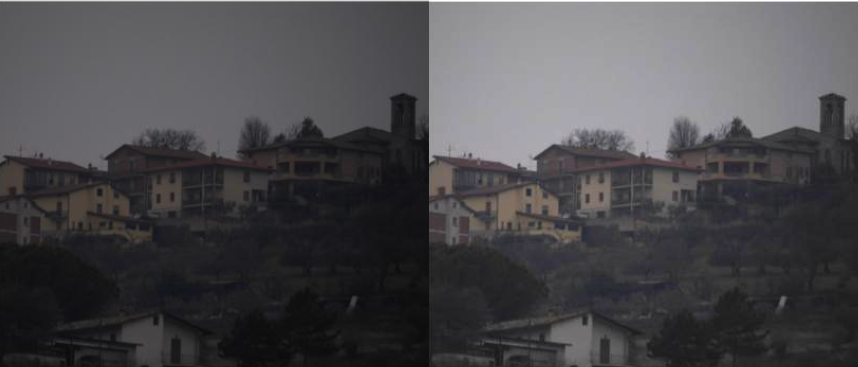

In [26]:
print('Mengubah kontras dan tingkat kecerahan citra')
print('-------------------------------------------')

try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    contrast = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/image/rumah.png')

# Penyesuaian Kontras dan Brightness: g(x,y) = a * f(x,y) + b
contrast_image = np.clip(contrast * img.astype(float) + brightness, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((img, contrast_image))
cv2_imshow(final_frame)

3. Transformasi Logarithmic Brightness
Formula: $s = c \cdot \log(1 + r)$

Mengubah tingkat kecerahan citra dengan Transformasi Log
-------------------------------------------------------
Masukkan nilai kecerahan (c): 50


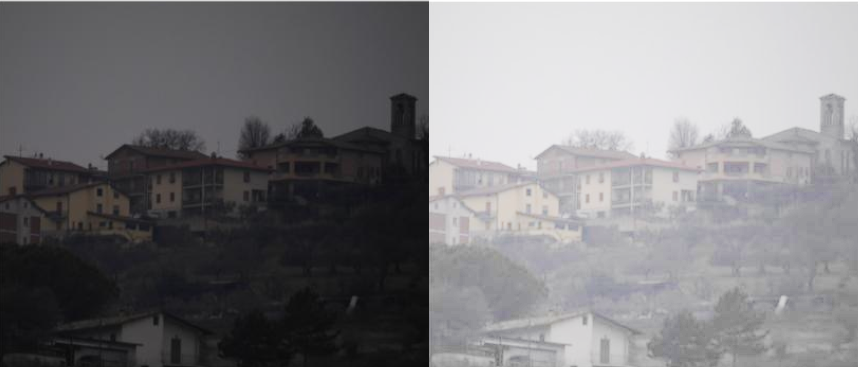

In [27]:
print('Mengubah tingkat kecerahan citra dengan Transformasi Log')
print('-------------------------------------------------------')

try:
    c = float(input('Masukkan nilai kecerahan (c): '))
except ValueError:
    print('Error, not a number')

img = cv.imread('/content/drive/MyDrive/PCVK/image/rumah.png')
img_float = img.astype(float)

# Transformasi Logaritma
log_image = c * (np.log(1 + img_float))
log_image = np.clip(log_image, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((img, log_image))
cv2_imshow(final_frame)

4. Grayscale (Averaging, Lightness, Luminance)

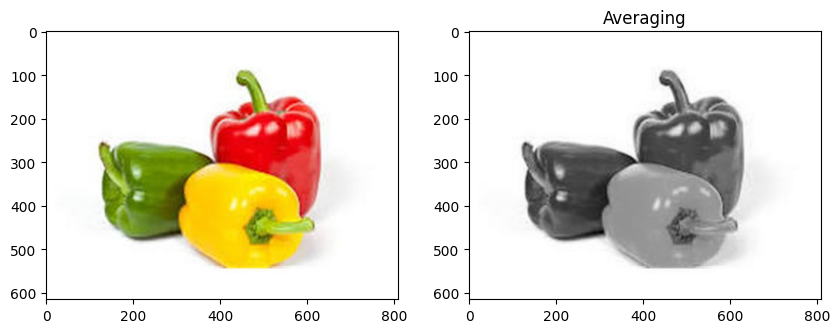

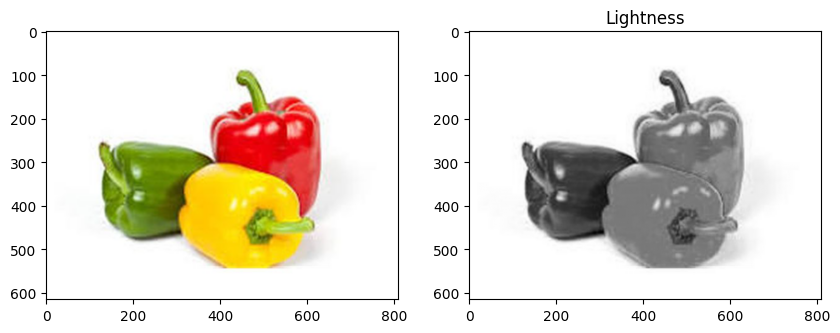

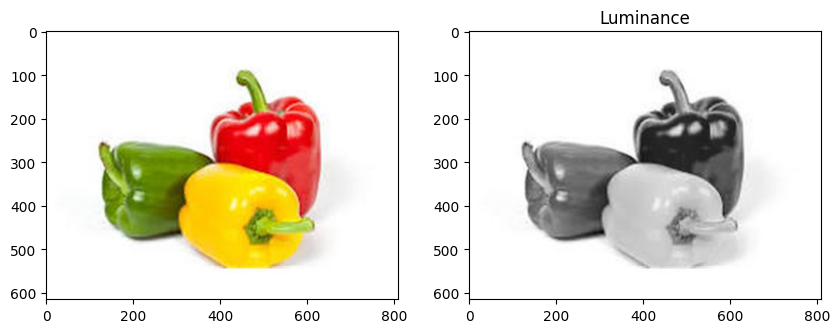

In [28]:
img = cv.imread('/content/drive/MyDrive/PCVK/image/Paprika.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

R = img_rgb[:, :, 0].astype(float)
G = img_rgb[:, :, 1].astype(float)
B = img_rgb[:, :, 2].astype(float)

# a. Averaging: (R + G + B) / 3
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# b. Lightness: (max(R,G,B) + min(R,G,B)) / 2
gray_lightness = ((np.maximum(np.maximum(R, G), B) + np.minimum(np.minimum(R, G), B)) / 2).astype(np.uint8)

# c. Luminance: 0.21*R + 0.72*G + 0.07*B
gray_luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

methods = [('Averaging', gray_avg), ('Lightness', gray_lightness), ('Luminance', gray_luminance)]

for title, gray_img in methods:
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.axis('on')

    plt.subplot(1, 2, 2)
    plt.imshow(gray_img, cmap='gray')
    plt.title(title)
    plt.axis('on')
    plt.show()

5. Mempertahankan Warna Merah & Mengubah Warna Lain Menjadi Grayscale

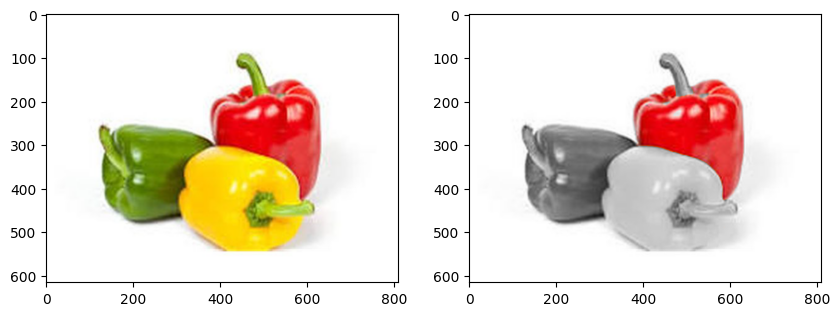

In [29]:
img = cv.imread('/content/drive/MyDrive/PCVK/image/Paprika.png')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Konversi ke HSV untuk isolasi warna merah dengan presisi
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# Rentang warna merah pada HSV
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)
red_mask = mask1 | mask2

# Buat versi Grayscale Luminance
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_3ch = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

# Gabungkan: Piksel merah tetap berpotongan dengan asli, sisa diisi grayscale
result = np.where(red_mask[:, :, None] == 255, img_rgb, gray_3ch)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.axis('on')
plt.show()

6. Aplikasi Gamma Correction
Formula: $I' = 255 \times \left(\frac{I}{255}\right)^\gamma$ atau $I' = 255 \times \left(\frac{I}{255}\right)^{\frac{1}{\gamma}}$

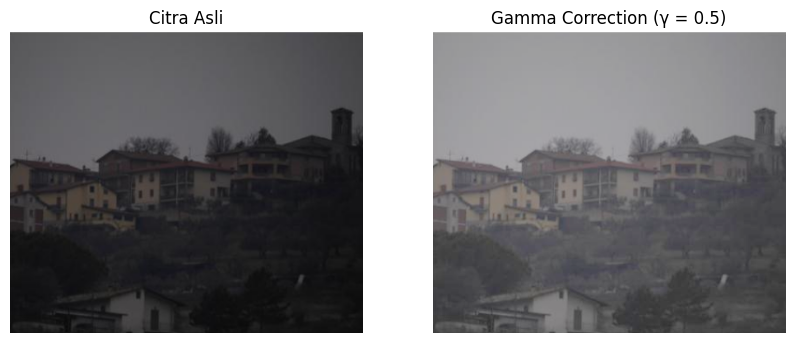

In [37]:
img = cv.imread('/content/drive/MyDrive/PCVK/image/rumah.png')

# Masukkan nilai gamma
gamma = 0.5

# menggunakan gamma
table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
gamma_img = cv.LUT(img, table)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(gamma_img, cv.COLOR_BGR2RGB))
plt.title(f'Gamma Correction (γ = {gamma})')
plt.axis('off')
plt.show()

7. Simulasi Image Bit Depth
Formula: $level = \frac{255}{2^{bit\_depth} - 1}$, $C' = \text{round}\left(\left(\frac{C}{level}\right) \times level\right)$

Masukkan bit depth tujuan (1-8): 3
Bit depth awal  : 8 bit
Bit depth tujuan: 3 bit
Jumlah level    : 8


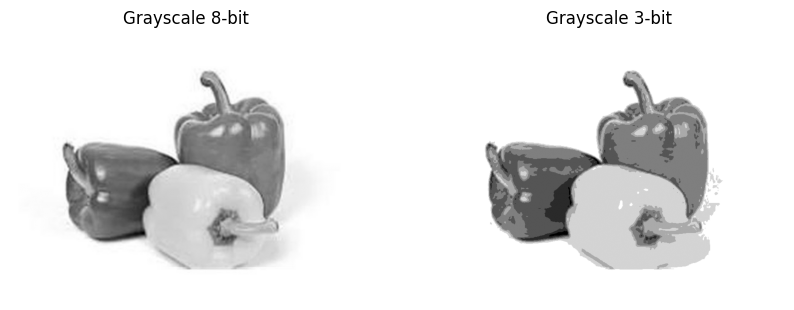

In [31]:
bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))

original = cv.imread('/content/drive/MyDrive/PCVK/image/Paprika.png', cv.IMREAD_GRAYSCALE)

if original is not None:
    level = 255.0 / (pow(2, bit_depth) - 1)
    depth_image = np.round(original / level) * level
    depth_image = depth_image.astype(np.uint8)

    print(f"Bit depth awal  : 8 bit")
    print(f"Bit depth tujuan: {bit_depth} bit")
    print(f"Jumlah level    : {pow(2, bit_depth)}")

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Grayscale 8-bit')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(depth_image, cmap='gray')
    plt.title(f'Grayscale {bit_depth}-bit')
    plt.axis('off')
    plt.show()

8. Buat modul Average Denoising

In [32]:
import cv2 as cv
import numpy as np
import math
import matplotlib.pyplot as plt

def calculate_psnr(img1, img2):
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

# 1. Baca gambar asli
original_img = cv.imread('/content/drive/MyDrive/PCVK/image/Galaxy.png')

# 2. Generate 100 gambar dengan Gaussian Noise secara otomatis
noisy_images = []
np.random.seed(42) # Agar hasil terprediksi

for i in range(100):
    noise = np.random.normal(0, 25, original_img.shape)
    noisy_img = np.clip(original_img.astype(float) + noise, 0, 255).astype(np.uint8)
    noisy_images.append(noisy_img)

# 3. Hitung Average Denoising untuk 10, 20, 40, 80, 100 gambar
counts = [10, 20, 40, 80, 100]
results_psnr = []
avg_results = {}

print("=== Hasil Average Denoising ===")
for N in counts:
    # Ambil N gambar pertama dan rata-ratakan
    sub_list = noisy_images[:N]
    avg_img = np.mean(sub_list, axis=0).astype(np.uint8)

    # Hitung PSNR
    psnr_val = calculate_psnr(original_img, avg_img)
    results_psnr.append(psnr_val)
    avg_results[N] = avg_img

    print(f"Jumlah Citra di Average: {N:3d} | PSNR: {psnr_val:.2f} dB")

=== Hasil Average Denoising ===
Jumlah Citra di Average:  10 | PSNR: 29.40 dB
Jumlah Citra di Average:  20 | PSNR: 30.86 dB
Jumlah Citra di Average:  40 | PSNR: 31.83 dB
Jumlah Citra di Average:  80 | PSNR: 32.41 dB
Jumlah Citra di Average: 100 | PSNR: 32.54 dB


Analisis dan Kesimpulan:
1. Apakah peningkatan jumlah citra selalu memberikan peningkatan PSNR yang signifikan?
Tidak selalu linear. Pada awalnya (dari 10 ke 40 citra), nilai PSNR naik secara drastis karena Gaussian noise acak saling meniadakan saat dirata-ratakan.

2. Pada jumlah citra berapa peningkatan mulai tidak terlalu signifikan?
Peningkatan mulai melambat/stagnan setelah mencapai sekitar 50 hingga 80 citra, di mana perbedaan kenaikan PSNR menjadi sangat kecil per tambahan gambar

3. Kesimpulan:
Operasi averaging sangat efektif mereduksi noise acak (seperti Gaussian noise). Semakin banyak citra yang dirata-ratakan, kualitas citra bersihnya meningkat (PSNR lebih tinggi). Namun, terdapat diminishing return di mana penambahan sampel berlebih tidak lagi memberikan peningkatan kualitas yang sepadan dengan beban komputasi.

9. Image Masking Menggunakan Operator Logika

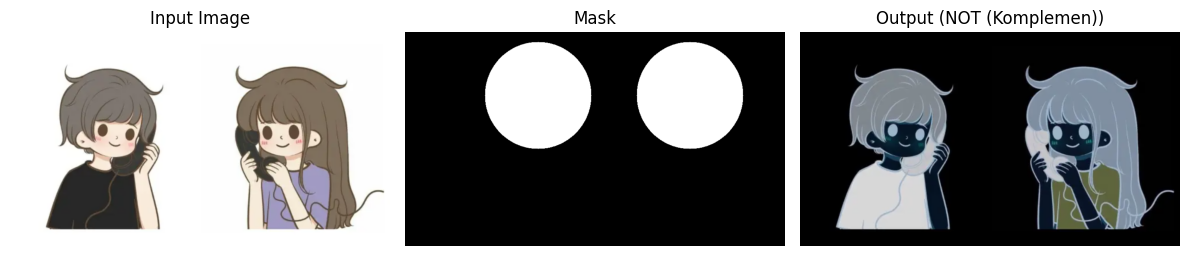

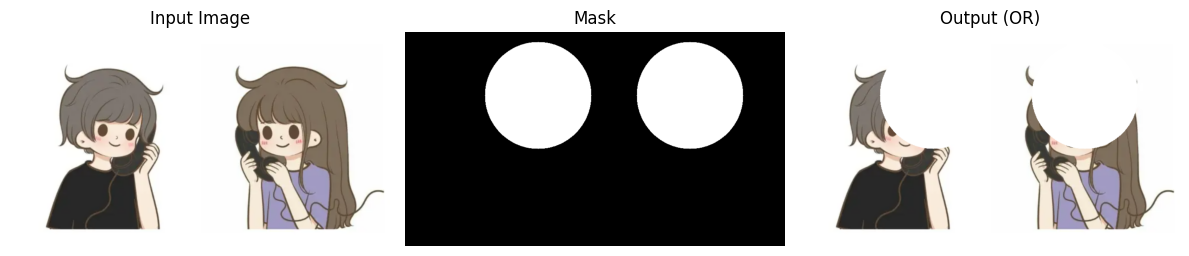

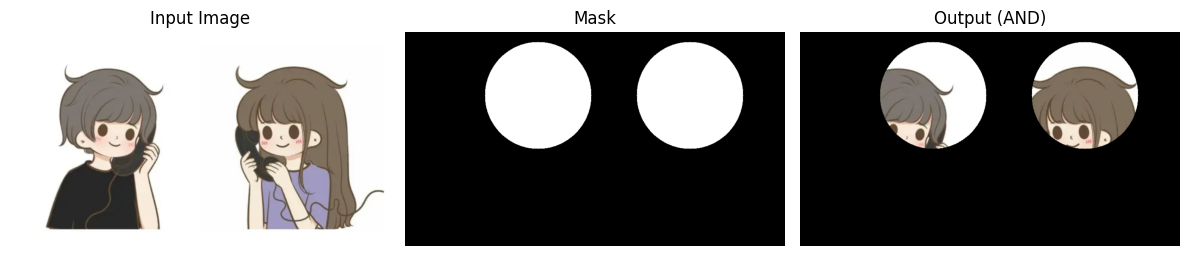

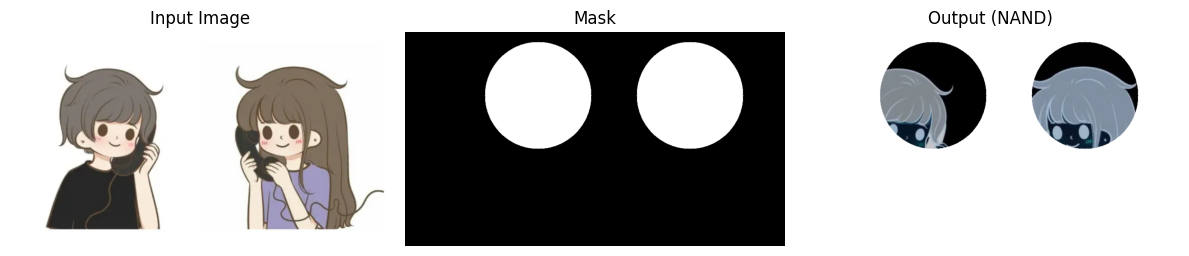

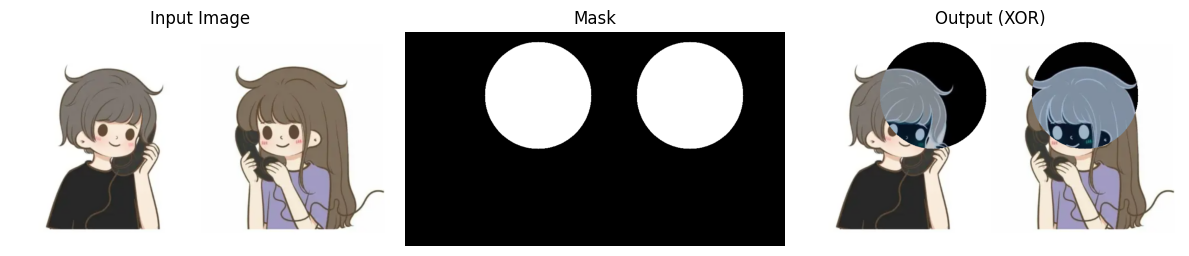

In [33]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/image/couple.png')

# 2. Membuat masker lingkaran
mask = np.zeros(img.shape[:2], dtype=np.uint8)
h, w = mask.shape
r = int(min(h, w) * 0.25)
cv.circle(mask, (int(w * 0.35), int(h * 0.3)), r, 255, -1)
cv.circle(mask, (int(w * 0.75), int(h * 0.3)), r, 255, -1)

# Konversi mask ke 3 channel agar match dengan citra BGR
mask_3ch = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)

# 3. Operasi Logika
op_not = cv.bitwise_not(img)
op_or = cv.bitwise_or(img, mask_3ch)
op_and = cv.bitwise_and(img, mask_3ch)
op_nand = cv.bitwise_not(op_and)
op_xor = cv.bitwise_xor(img, mask_3ch)

operators = [
    ("NOT (Komplemen)", op_not),
    ("OR", op_or),
    ("AND", op_and),
    ("NAND", op_nand),
    ("XOR", op_xor)
]

# 4. Tampilkan Hasil
for title, res in operators:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    axes[0].set_title("Input Image")
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Mask")
    axes[1].axis('off')

    axes[2].imshow(cv.cvtColor(res, cv.COLOR_BGR2RGB))
    axes[2].set_title(f"Output ({title})")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

Analisa :
1. NOT (Komplemen): Membalikkan seluruh nilai intensitas biner piksel citra ($255 - X$). Warna terang berubah menjadi gelap dan warna gelap menjadi terang, menghasilkan efek citra negatif tanpa terpengaruh oleh mask
2. OR (Atau): Menggabungkan piksel citra asli dengan mask. Area lingkaran mask yang bernilai 255 (putih) akan dipaksa menjadi warna putih penuh pada hasil akhir, sedangkan area di luar lingkaran (hitam/0) tetap menampilkan gambar asli.
3. AND (Dan): Menampilkan piksel citra hanya pada area mask yang bernilai 255 (putih). Area di luar lingkaran mask (0/hitam) otomatis dipotong dan berubah menjadi latar belakang hitam murni (efek cropping lingkaran).
4. NAND (Not AND): Merupakan kebalikan dari operasi AND. Area di dalam lingkaran mask diinversi warna aslinya, sedangkan area di luar lingkaran yang tadinya dipotong hitam diubah menjadi warna putih terang.
5. XOR (Exclusive OR): Hanya mengaktifkan piksel jika salah satu input bernilai aktif. Pada area mask putih, warna citra asli akan diinversi (negatif), sementara pada area mask hitam, warna citra asli tetap normal tanpa perubahan.

10. Pengolahan Foto Malam Hari (Dark Image Enhancement)

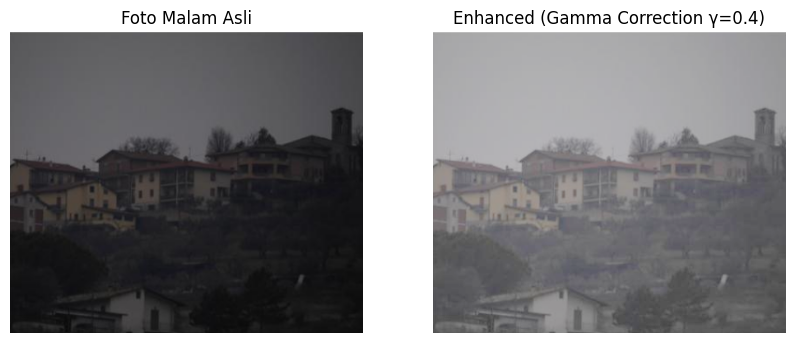

In [35]:
dark_img = cv.imread('/content/drive/MyDrive/PCVK/image/rumah.png')

# Terapkan Gamma Correction (Gamma < 1 untuk mencerahkan bayangan)
gamma = 0.4

# Gunakan 'gamma' langsung sebagai pangkat, bukan 'invGamma'
table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
enhanced_dark = cv.LUT(dark_img, table)

# Visualisasi
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(dark_img, cv.COLOR_BGR2RGB))
plt.title('Foto Malam Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(enhanced_dark, cv.COLOR_BGR2RGB))
plt.title('Enhanced (Gamma Correction γ=0.4)')
plt.axis('off')
plt.show()

Metode yang Dipilih: Gamma Correction ($\gamma < 1.0$, misal $\gamma = 0.4$)

Alasan Pemilihan:
Pada foto malam hari, distribusi intensitas piksel sangat dominan di area gelap (skala nilai rendah). Gamma Correction non-linear mampu meregangkan intensitas gelap (shadows) tanpa membuat area yang sudah terang (highlights) menjadi terlalu pecah/overexposed. Transformasi linier brightness biasa akan merusak detail di titik terang.

Resiko:
Menaikkan daerah gelap secara drastis akan memunculkan digital noise (seperti chroma/luminance noise) yang sebelumnya tersembunyi di area gelap.

11. Perbaikan Kualitas Citra crayfish

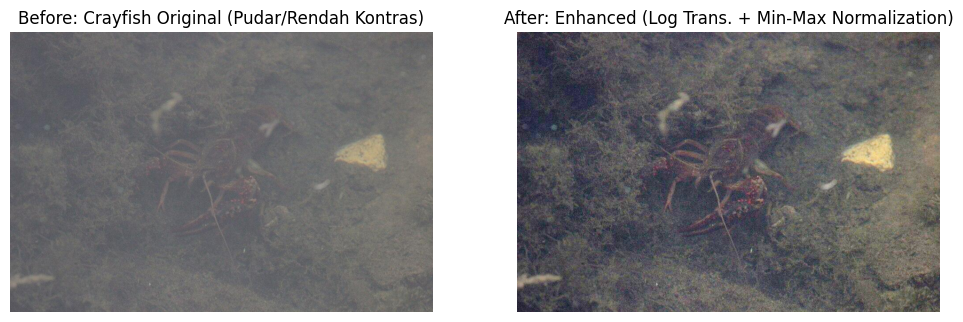

In [36]:
# 1. Baca Gambar
crayfish = cv.imread('/content/drive/MyDrive/PCVK/image/Crayfish.png')

# 2. Kombinasi Metode: Logarithmic Transformation + Contrast Stretching
# a. Logarithmic Brightness (Meningkatkan visibilitas area sangat gelap)
crayfish_float = crayfish.astype(float)
c = 42.0  # Konstanta pengali
log_crayfish = c * np.log(1 + crayfish_float)
log_crayfish = np.clip(log_crayfish, 0, 255).astype(np.uint8)

# b. Contrast Stretching / Histogram Normalization
# Meredistribusi rentang dinamis piksel agar lebih tajam
gray_log = cv.cvtColor(log_crayfish, cv.COLOR_BGR2GRAY)
norm_crayfish = cv.normalize(log_crayfish, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX)

# Visualisasi Before - After
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(crayfish, cv.COLOR_BGR2RGB))
plt.title('Before: Crayfish Original (Pudar/Rendah Kontras)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(norm_crayfish, cv.COLOR_BGR2RGB))
plt.title('After: Enhanced (Log Trans. + Min-Max Normalization)')
plt.axis('off')
plt.show()

Metode yang Dipilih: Combined Logarithmic Brightness Transformation dan Min-Max Contrast Normalization.

Alasan Pemilihan: Citra crayfish.jpg mengalami masalah pudar (hazy/low contrast) dan tertutup kabut gelap. Transformasi logaritma mampu menaikkan nilai piksel intensitas rendah, lalu dinormalisasi (contrast stretch) untuk meregangkan sebaran kontras agar objek utama kelihatan jelas dan tajam

Menentukan Parameter Terbaik: Nilai konstanta log $c = 42.0$ dipilih secara empiris agar kecerahan latar belakang naik secara pas tanpa menghilangkan detail warna udang/crayfish.